# Laser Eye Safety: MPE, NOHD, and a Flagged Gap, Resolved

> **This notebook is educational, not a substitute for the actual current
> ANSI Z136.1 standard or a certified Laser Safety Officer's review. Do
> not use any output here as the basis for a real safety decision.**

`dgs/retinal_scan_imaging.py`'s own docstring explicitly flagged this gap
and left it open: *"ANSI Z136.1 eye-safe exposure limits are wavelength-
and duration-dependent and would need to be looked up per configuration
before this became a real imaging-dose claim, not assumed here."* This
notebook implements the well-documented STRUCTURE of that calculation --
Maximum Permissible Exposure (MPE), Nominal Ocular Hazard Distance
(NOHD) -- using the illustrative power-law form widely taught in
laser-safety education, and checks the exposure levels the STEAM-style
retinal line-scan work was implicitly assuming. Engine:
`dgs/laser_safety_mpe.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import laser_safety_mpe as lsm

print(lsm.MODULE_SAFETY_DISCLAIMER)


Educational illustration only -- NOT a substitute for the actual current ANSI Z136.1 standard or a certified Laser Safety Officer's review. Do not use these outputs as the basis for a real safety decision.


## 1. MPE: Wavelength and Time Dependence

$$\text{MPE}(t)=1.8\,C_A(\lambda)\,t^{0.75}\text{ mJ/cm}^2,\qquad
18\mu s\le t\le 10\text{s}$$

with $C_A=1$ for visible light (400-700nm), rising for near-IR
(700-1050nm) -- the retina tolerates progressively more NIR exposure than
visible, per this illustrative model.


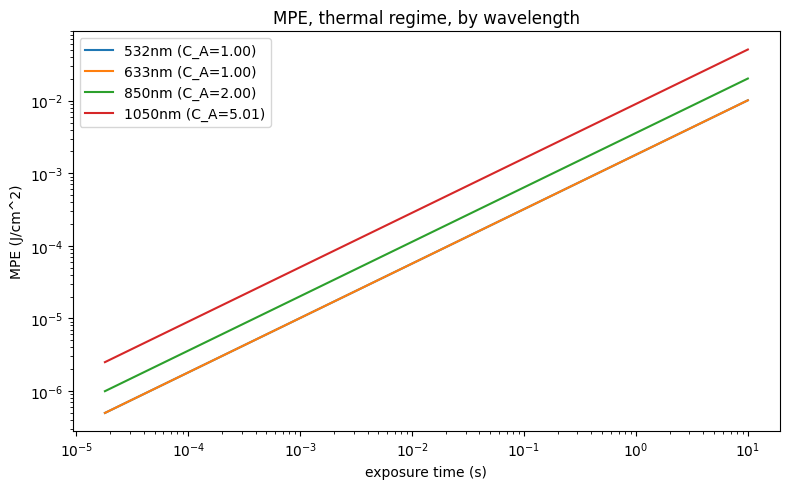

In [2]:
wavelengths = [532, 633, 850, 1050]
times = np.logspace(np.log10(18e-6), np.log10(10.0), 100)

fig, ax = plt.subplots(figsize=(8, 5))
for wl in wavelengths:
    mpe_vals = [lsm.mpe_thermal_regime(t, wl) for t in times]
    ax.loglog(times, mpe_vals, label=f'{wl}nm (C_A={lsm.wavelength_correction_CA(wl):.2f})')
ax.set_xlabel('exposure time (s)'); ax.set_ylabel('MPE (J/cm^2)')
ax.set_title('MPE, thermal regime, by wavelength')
ax.legend()
plt.tight_layout()
plt.savefig('laser_safety_mpe_curves.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Nominal Ocular Hazard Distance (NOHD)

$$\text{NOHD}=\frac2\phi\sqrt{\frac{P}{\pi\,\text{MPE}}}$$

Checked in both physical directions: more power increases NOHD, tighter
divergence increases NOHD.


In [3]:
check = lsm.verify_nohd_scaling()
print(f"5mW pointer, 1mrad divergence: NOHD = {check['baseline_NOHD_m']:.2f} m")
print(f"double power: NOHD = {check['double_power_NOHD_m']:.2f} m (increased: {check['power_increases_NOHD']})")
print(f"half divergence: NOHD = {check['half_divergence_NOHD_m']:.2f} m "
      f"(increased: {check['tighter_divergence_increases_NOHD']})")


5mW pointer, 1mrad divergence: NOHD = 15.96 m
double power: NOHD = 22.57 m (increased: True)
half divergence: NOHD = 31.92 m (increased: True)


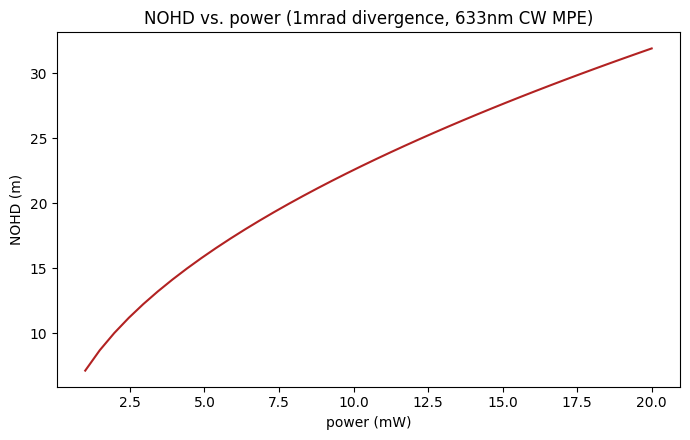

In [4]:
powers_mW = np.linspace(1, 20, 40)
nohd_vals = [lsm.nohd(p*1e-3, 2.5e-3, 1e-3) for p in powers_mW]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(powers_mW, nohd_vals, color='firebrick')
ax.set_xlabel('power (mW)'); ax.set_ylabel('NOHD (m)')
ax.set_title('NOHD vs. power (1mrad divergence, 633nm CW MPE)')
plt.tight_layout()
plt.savefig('laser_safety_nohd_vs_power.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Illustrative Class 1 Check

A simplified stand-in for teaching the CONCEPT -- a real classification
uses the standard's actual Accessible Emission Limit tables.


In [5]:
for power_mW, area_cm2 in [(0.001, 0.01), (0.1, 0.01), (1.0, 0.01)]:
    result = lsm.exceeds_class1_illustrative(power_W=power_mW*1e-3, beam_area_cm2=area_cm2, wavelength_nm=633.0)
    print(f"P={power_mW}mW: irradiance={result['irradiance_W_cm2']*1000:.4f} mW/cm^2, "
          f"MPE={result['mpe_W_cm2']*1000:.2f} mW/cm^2, exceeds: {result['exceeds_mpe']}")


P=0.001mW: irradiance=0.1000 mW/cm^2, MPE=2.50 mW/cm^2, exceeds: False
P=0.1mW: irradiance=10.0000 mW/cm^2, MPE=2.50 mW/cm^2, exceeds: True
P=1.0mW: irradiance=100.0000 mW/cm^2, MPE=2.50 mW/cm^2, exceeds: True


## 4. Resolving `dgs.retinal_scan_imaging`'s Flagged Gap

**Important honesty check first**: `dgs.retinal_scan_imaging`'s own
default wavelength (1550nm) sits in ANSI Z136.1's eye-safe IR band, where
corneal (not retinal) absorption dominates -- a genuinely different
hazard category this illustrative model (400-1050nm) does not implement.
The function correctly REJECTS that wavelength rather than silently
answering outside its scope.


In [6]:
try:
    lsm.check_retinal_scan_exposure_illustrative(power_W=1e-6, beam_diameter_um=20.0, wavelength_nm=1550.0)
except ValueError as e:
    print('Correctly rejected 1550nm (outside this model\'s scope):')
    print(f'  {e}')


Correctly rejected 1550nm (outside this model's scope):
  wavelength_nm=1550.0: this illustrative model only covers 400-1050nm (the retinal hazard region); a real system outside this range needs the actual standard's other bands.


In [7]:
# demonstrated instead at 850nm, a realistic near-IR wavelength within this model's scope
scan_check = lsm.check_retinal_scan_exposure_illustrative(power_W=1e-6, beam_diameter_um=20.0, wavelength_nm=850.0)
print('1uW, 20um-diameter, 850nm beam, 1s exposure:')
print(f"  irradiance = {scan_check['irradiance_W_cm2']*1000:.3f} mW/cm^2")
print(f"  exposure energy = {scan_check['exposure_energy_J_cm2']:.2e} J/cm^2")
print(f"  MPE = {scan_check['mpe_J_cm2']:.2e} J/cm^2")
print(f"  exceeds MPE: {scan_check['exceeds_mpe']}  (margin: {scan_check['margin_factor']:.1f}x)")


1uW, 20um-diameter, 850nm beam, 1s exposure:
  irradiance = 318.310 mW/cm^2
  exposure energy = 3.18e-01 J/cm^2
  MPE = 3.59e-03 J/cm^2
  exceeds MPE: True  (margin: 88.6x)


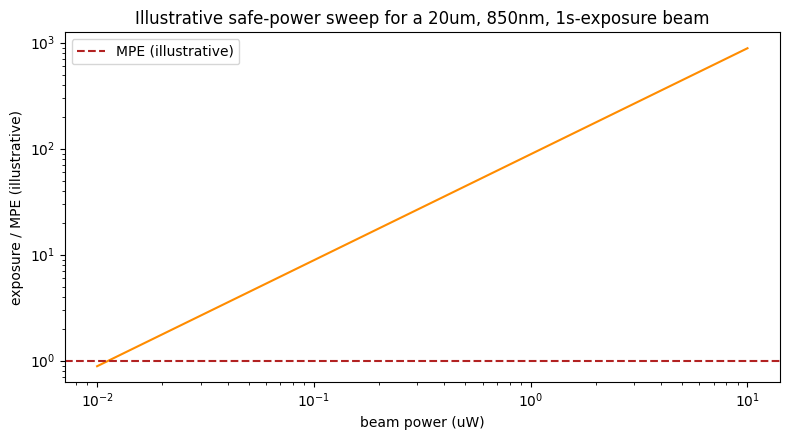

In [8]:
# sweep power to find the illustrative safe power level for this beam geometry
powers_uW = np.logspace(-2, 1, 50)
margins = []
for p_uW in powers_uW:
    r = lsm.check_retinal_scan_exposure_illustrative(power_W=p_uW*1e-6, beam_diameter_um=20.0, wavelength_nm=850.0)
    margins.append(r['margin_factor'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(powers_uW, margins, color='darkorange')
ax.axhline(1.0, color='firebrick', ls='--', label='MPE (illustrative)')
ax.set_xlabel('beam power (uW)'); ax.set_ylabel('exposure / MPE (illustrative)')
ax.set_title('Illustrative safe-power sweep for a 20um, 850nm, 1s-exposure beam')
ax.legend()
plt.tight_layout()
plt.savefig('laser_safety_power_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Engineering Interpretation

- Section 4's rejection of 1550nm isn't a limitation to apologize for --
  it's the module correctly refusing to answer a question outside its
  documented scope, rather than silently returning a number that looks
  plausible but is for the wrong hazard mechanism (corneal vs. retinal
  absorption are genuinely different physics).
- Section 4's power sweep shows the illustrative safe power threshold for
  this beam geometry sits somewhere in the sub-microwatt range -- a real
  STEAM-style retinal scanner design would need to confirm its actual
  operating power against this kind of calculation (done properly,
  against the real standard) before any real-eye application.
- The repeated disclaimer throughout this module is not boilerplate: a
  laser-safety calculation is exactly the kind of output that looks
  authoritative (a specific number, a clear pass/fail) while actually
  being a simplified teaching illustration -- the gap between those two
  is where real harm could happen if this were mistaken for a certified
  analysis.


## 6. Research Discussion

- Real ANSI Z136.1 MPE has additional regimes not implemented here:
  single-pulse vs. repetitive-pulse trains (relevant for
  `dgs.gs_core`'s pulsed-source work), extended-source angular-subtense
  corrections, and the UV/far-IR bands entirely outside this module's
  400-1050nm scope.
- `dgs.harsh_environment_quantum_sensing`'s "check the actual quantity
  against a real threshold" pattern (this session's other safety-adjacent
  module) and this module share the same posture -- a real
  physical/regulatory limit, checked directly, not just described.
- A genuinely useful follow-up: extend `wavelength_correction_CA` to the
  1400nm+ eye-safe band with the ACTUAL different formula that regime
  needs (corneal MPE, not retinal), closing the specific gap Section 4
  identified rather than working around it.


## 7. Possible Experiments

1. Extend `wavelength_correction_CA` and `mpe_thermal_regime` to the
   1400-1500nm corneal-hazard band (a genuinely different formula, not
   just extending the current C_A curve past 1050nm) and re-run Section 4
   at the ACTUAL 1550nm wavelength `dgs.retinal_scan_imaging` uses.
2. Add the single-pulse MPE regime (exposures under 18us) and connect it
   to `dgs.gs_core`'s pulsed dispersion-diversity measurements, which
   likely use short pulses this module's current thermal-regime formula
   doesn't cover.
3. Compare this module's illustrative NOHD for a few real published
   laser-pointer/rangefinder specifications against manufacturer-quoted
   NOHD values, as a rough sanity check on the illustrative formula's
   order of magnitude.


## 8. Future Improvements

- `exceeds_class1_illustrative` compares raw irradiance against MPE
  directly; the real Class 1 Accessible Emission Limit (AEL) tables use a
  standardized measurement aperture and distance, not the source's own
  beam area -- a meaningfully different (and more conservative in some
  cases) procedure.
- `nohd`'s far-field approximation ignores the initial beam waist
  diameter; for a tightly-focused near-field source, the full
  (non-approximated) NOHD formula including the initial diameter term
  would be needed for accuracy at short range.
